# EDA

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv(r"K:\End-to-End-Airbnb-Price-Prediction-ML-System\artifacts\processed_data\cleaned_airbnb_data.csv")

df.head()

,log_price,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,...,host_response_rate,instant_bookable,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,amenities_count,host_years
0,5.010635,Apartment,Entire home/apt,3,1.0,Real Bed,strict,1,NYC,1,...,100.0,0,40.696524,-73.991617,2,100.0,1.0,1.0,9,14.0
1,5.129899,Apartment,Entire home/apt,7,1.0,Real Bed,strict,1,NYC,1,...,100.0,1,40.766115,-73.989040,6,93.0,3.0,3.0,15,9.0
2,4.976734,Apartment,Entire home/apt,5,1.0,Real Bed,moderate,1,NYC,1,...,100.0,1,40.808110,-73.943756,10,92.0,1.0,3.0,19,10.0
3,6.620073,House,Entire home/apt,4,1.0,Real Bed,flexible,1,SF,1,...,100.0,0,37.772004,-122.431619,0,96.0,2.0,2.0,15,11.0
4,4.744932,Apartment,Entire home/apt,2,1.0,Real Bed,moderate,1,DC,1,...,100.0,1,38.925627,-77.034596,4,40.0,0.0,1.0,12,11.0


1. Correlation Heatmap

In [10]:
df.select_dtypes(include=["int",'float']).columns

Index(['log_price', 'accommodates', 'bathrooms', 'cleaning_fee',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'instant_bookable', 'latitude', 'longitude', 'number_of_reviews',
       'review_scores_rating', 'bedrooms', 'beds', 'amenities_count',
       'host_years'],
      dtype='object')

In [11]:
df.select_dtypes(include=["int",'float']).corr().round(2)

,log_price,accommodates,bathrooms,cleaning_fee,host_has_profile_pic,host_identity_verified,host_response_rate,instant_bookable,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,amenities_count,host_years
log_price,1.00,0.57,0.36,0.11,-0.01,0.02,0.00,-0.04,-0.00,-0.05,-0.03,0.08,0.47,0.44,0.19,0.08
accommodates,0.57,1.00,0.51,0.18,0.01,0.06,0.02,0.05,-0.08,-0.09,0.04,-0.02,0.71,0.81,0.26,-0.01
bathrooms,0.36,0.51,1.00,0.05,0.01,0.02,-0.00,0.00,-0.14,-0.13,-0.04,0.01,0.59,0.53,0.16,-0.01
cleaning_fee,0.11,0.18,0.05,1.00,0.02,0.16,0.05,0.01,-0.06,-0.07,0.11,-0.00,0.11,0.13,0.24,0.09
host_has_profile_pic,-0.01,0.01,0.01,0.02,1.00,0.10,0.00,-0.00,-0.02,-0.02,0.02,-0.00,0.01,0.01,0.02,0.02
host_identity_verified,0.02,0.06,0.02,0.16,0.10,1.00,0.05,-0.09,-0.05,-0.06,0.16,0.02,0.03,0.04,0.14,0.33
host_response_rate,0.00,0.02,-0.00,0.05,0.00,0.05,1.00,0.07,0.02,0.00,0.07,0.05,0.01,0.02,0.08,0.01
instant_bookable,-0.04,0.05,0.00,0.01,-0.00,-0.09,0.07,1.00,-0.01,-0.00,0.08,-0.06,-0.00,0.05,0.10,-0.19
latitude,-0.00,-0.08,-0.14,-0.06,-0.02,-0.05,0.02,-0.01,1.00,0.90,-0.02,-0.03,-0.06,-0.08,-0.05,0.01
longitude,-0.05,-0.09,-0.13,-0.07,-0.02,-0.06,0.00,-0.00,0.90,1.00,-0.05,-0.04,-0.08,-0.08,-0.08,-0.01


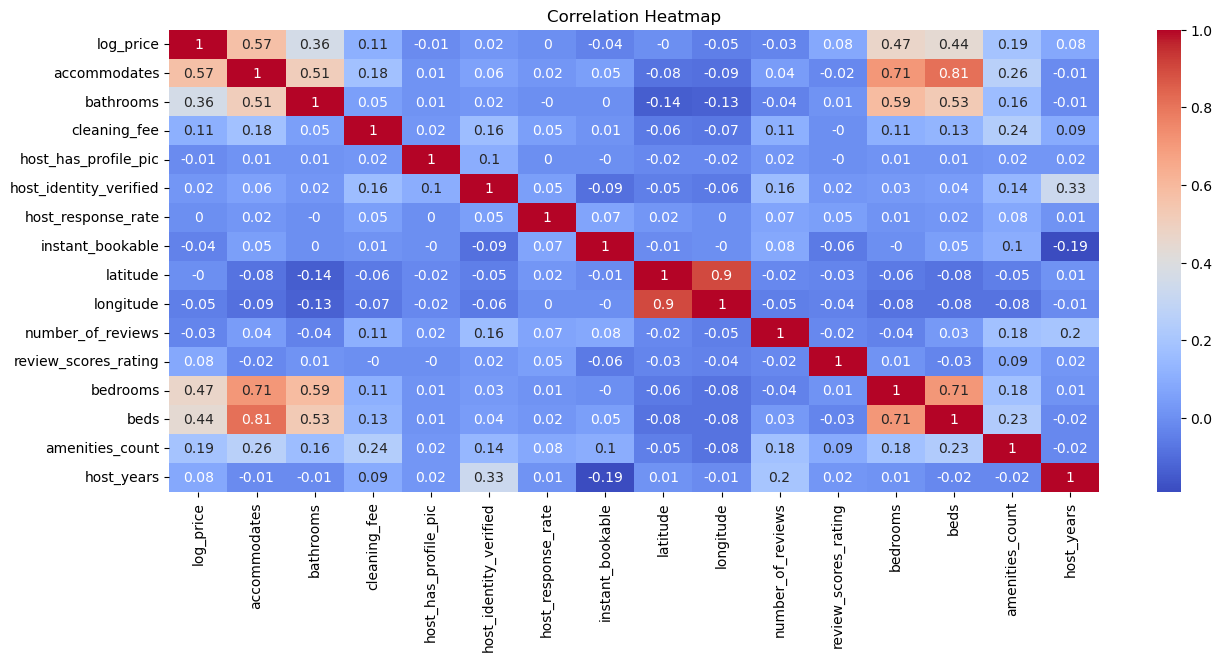

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(15,6))
sns.heatmap(numeric_df.corr().round(2), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation
The strongest positive relationship with log_price is accommodates at about 0.57, followed by bedrooms around 0.47, beds around 0.44, and bathrooms around 0.36. This means listing size and guest capacity are the main drivers of price.

amenities_count has a smaller but positive relationship, so more amenities generally increase price, but not as strongly as capacity-related features.

host_response_rate, instant_bookable, and number_of_reviews have near-zero correlation with price, so they are weaker direct predictors.

2. Target Variable Distribution

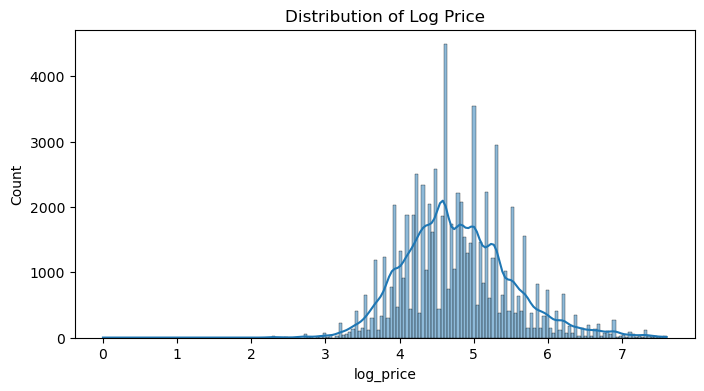

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df['log_price'], kde=True)
plt.title("Distribution of Log Price")
plt.show()

### Interpretation

The log_price distribution looks roughly bell-shaped with slight right skew. That is a good sign because the log transform has reduced the heavy skewness usually seen in raw prices.

This supports your choice of predicting log_price instead of raw price. It makes the regression problem more stable and improves model performance.

3. Relationship Between Price and Key Numerical Features

Price vs Accommodates

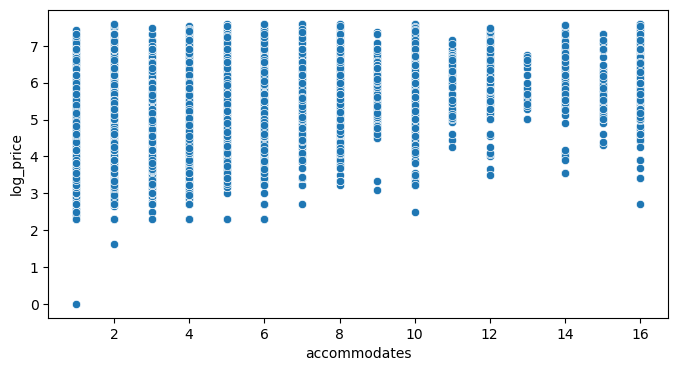

In [14]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='accommodates', y='log_price', data=df)
plt.show()

### Interpratation

There is a clear upward pattern. As the number of guests a property can accommodate increases, the price also tends to increase.

At the same time, the spread is wide for each value, which means capacity matters a lot, but it is not the only factor affecting price. This is realistic for Airbnb data.

Price vs Bedrooms

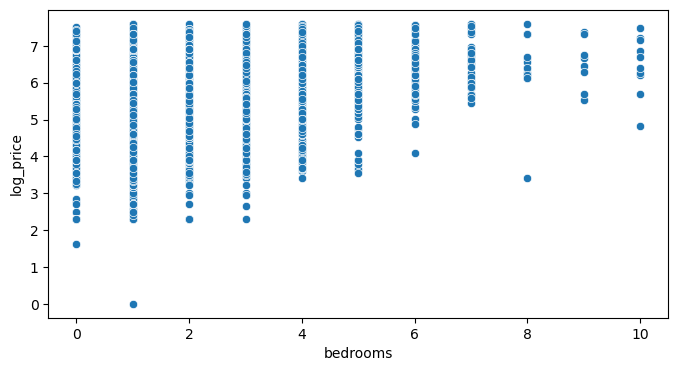

In [15]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='bedrooms', y='log_price', data=df)
plt.show()

### Interpretation 
This plot also shows a positive relationship. Listings with more bedrooms generally have higher prices.

Again, there is noticeable spread, which means two listings with the same number of bedrooms can still have different prices due to other features like room type, location, amenities, and property type.

4. Categorical Feature Analysis

Room Type vs Price

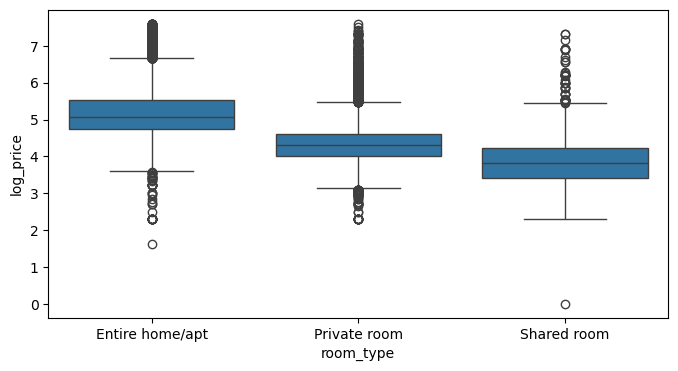

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='room_type', y='log_price', data=df)
plt.show()

### Interpretationn 
This is one of the strongest visual findings.

* Entire home/apt has the highest median log price
* Private room is lower
* Shared room is the lowest

This is very intuitive and important. It shows that room type is a key categorical factor in pricing. Entire homes offer more privacy and space, so they command higher prices.

5. Top 10 Property Type vs Price

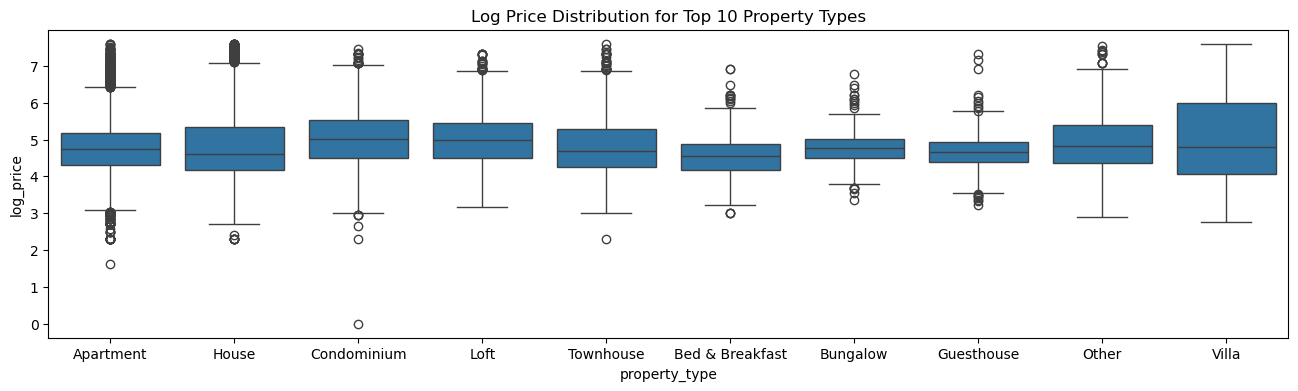

In [17]:
top_10_property_types = df['property_type'].value_counts().head(10).index
df_filtered = df[df['property_type'].isin(top_10_property_types)]

plt.figure(figsize=(16, 4))
sns.boxplot(x='property_type', y='log_price', data=df_filtered)
plt.title('Log Price Distribution for Top 10 Property Types')
plt.show()

### Interpretation

Different property types show different price levels.

* Villa appears to have one of the highest price ranges and greater variability
* Condominium, Loft, and Townhouse also tend to have relatively high prices
* Bed & Breakfast, Bungalow, and Guesthouse appear somewhat lower on average

This tells us that property type influences price, but the effect is less consistent than room type because there is overlap across categories.

6. Top Factors Affecting Price

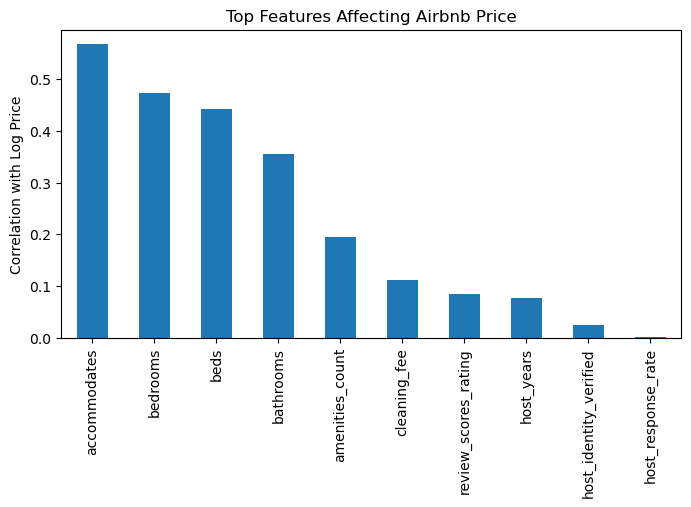

In [18]:
corr = df.corr(numeric_only=True)['log_price'].sort_values(ascending=False)

plt.figure(figsize=(8,4))
corr.drop('log_price').head(10).plot(kind='bar')
plt.title("Top Features Affecting Airbnb Price")
plt.ylabel("Correlation with Log Price")
plt.show()

### Interpretation 
This chart confirms the earlier analysis.

Top features are:

* accommodates
* bedrooms
* beds
* bathrooms

Then moderate features:

* amenities_count
* cleaning_fee

Weak features:

* review_scores_rating
* host_years
* host_identity_verified
* host_response_rate

So your final conclusion should be that property size/capacity features are the strongest predictors of Airbnb price, while host-related features have much smaller influence.